In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.datasets
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn import metrics

In [ ]:
df=pd.read_csv("House_Price.csv")
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,price
0,57.5520,0.0,20.15,0,0.496,7.55,69.3,11.26,3,612,12.3,37.19,9.61,55.00
1,50.5164,80.0,17.72,1,0.495,6.74,81.9,1.07,6,612,15.4,61.71,36.42,33.23
2,8.3562,0.0,10.01,1,0.694,7.94,74.3,7.17,13,260,17.5,329.19,23.89,55.00
3,51.9659,80.0,2.34,0,0.782,8.92,86.3,10.96,13,464,16.5,331.06,7.02,55.00
4,60.3191,80.0,25.32,0,0.697,4.44,74.3,2.88,13,456,21.9,254.02,21.61,31.90


In [ ]:
df.shape

(1000, 14)

In [ ]:
df.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


In [ ]:
corr=df.corr()

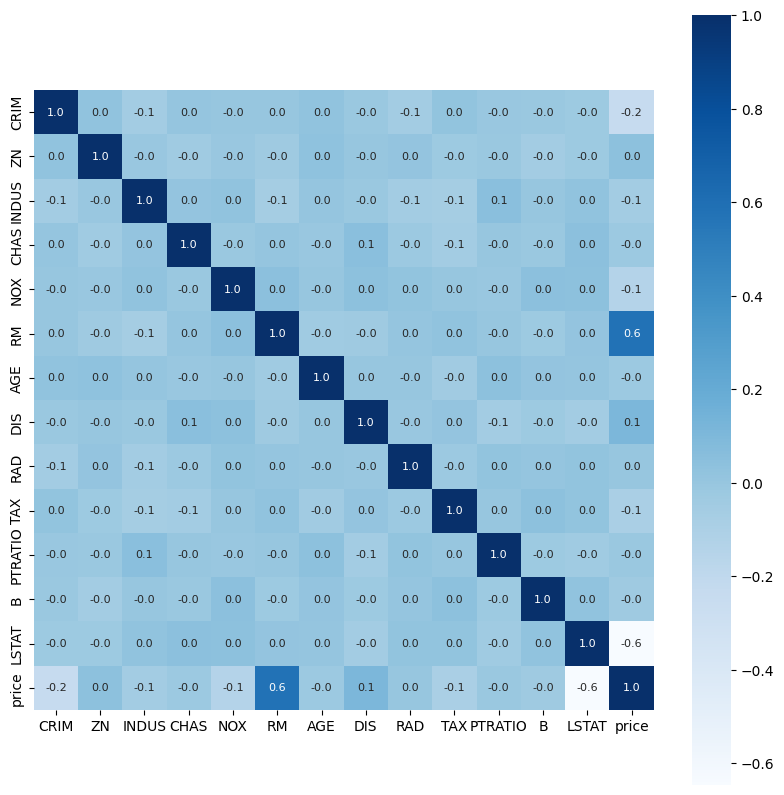

In [ ]:
plt.figure(figsize=(10,10))
sns.heatmap(corr,cbar=True, square=True,fmt='.1f',annot=True,annot_kws={'size':8},cmap='Blues')
plt.show()

In [ ]:
x=df.drop(['price'],axis=1)
y=df['price']

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
xg= XGBRegressor()

In [ ]:
xg.fit(x_train,y_train)
xg.score(x_test,y_test)*100

93.84210670335538

In [ ]:
s1=metrics.r2_score(y_train,xg.predict(x_train))
s2=metrics.mean_absolute_error(y_train,xg.predict(x_train))
s1,s2

(0.9999955125959095, 0.01594443173408501)

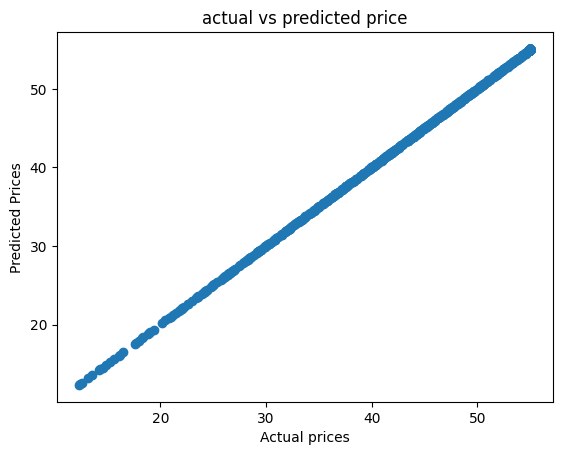

In [ ]:
plt.scatter(y_train,xg.predict(x_train))
plt.xlabel("Actual prices")
plt.ylabel("Predicted Prices")
plt.title("actual vs predicted price")
plt.show()

In [ ]:
s1=metrics.r2_score(y_test,xg.predict(x_test))
s2=metrics.mean_absolute_error(y_test,xg.predict(x_test))
s1,s2

(0.9384210670335539, 2.1204388961791993)

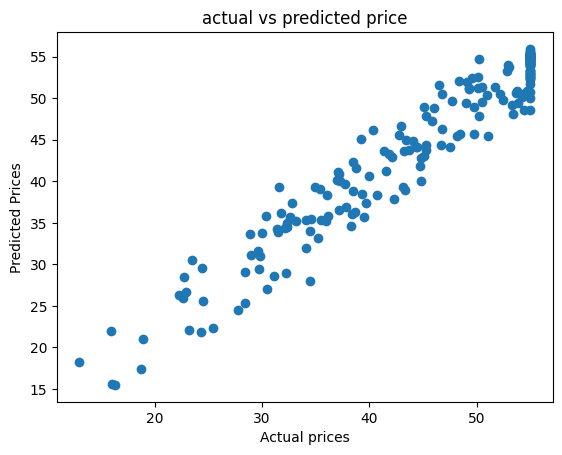

In [ ]:
plt.scatter(y_test,xg.predict(x_test))
plt.xlabel("Actual prices")
plt.ylabel("Predicted Prices")
plt.title("actual vs predicted price")
plt.show()